# Understanding charset.py / 文字集合の理解

`charset.py` builds the list of characters to render.
This notebook covers all input forms and how font filtering works.

In [1]:
from font2dataset.charset import (
    build_charset, get_preset, from_range,
    filter_by_font, supported_codepoints, PRESET_NAMES,
)

FONT = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
print("Ready")

Ready


## 1. Built-in Presets / 組み込みプリセット

In [2]:
print(f"{'Preset':<14} {'Count':>6}  {'First':<6} {'Last'}")
print("-" * 40)
for name in sorted(PRESET_NAMES):
    chars = get_preset(name)
    print(f"{name:<14} {len(chars):>6}  {chars[0]!r:<6} {chars[-1]!r}")

Preset          Count  First  Last
----------------------------------------
ascii              95  ' '    '~'
cjk_common      20902  '一'    '龥'
cyrillic           80  'А'    'џ'
digits             10  '0'    '9'
greek              57  'Α'    'ω'
hiragana           86  'ぁ'    'ゖ'
katakana           86  'ァ'    'ヶ'
latin_ext         192  'À'    'ſ'
lowercase          26  'a'    'z'
uppercase          26  'A'    'Z'


## 2. Input Forms Accepted by `build_charset` / 入力形式

Each spec string is interpreted in this order:
1. Preset name
2. Unicode range `"U+XXXX-U+YYYY"`
3. Literal characters (the string itself)

In [3]:
# ① preset name
chars, _ = build_charset("hiragana")
print(f"① preset       'hiragana'       → {len(chars)} chars: {chars[:5]}...")

# ② Unicode range string
chars, _ = build_charset("U+3041-U+3096")
print(f"② range        'U+3041-U+3096'  → {len(chars)} chars: {chars[:5]}...")

# ③ literal string
chars, _ = build_charset("あいうえお")
print(f"③ literal      'あいうえお'      → {chars}")

# ③ list of single chars
chars, _ = build_charset(["A", "B", "C"])
print(f"③ char list    ['A','B','C']     → {chars}")

# combined
chars, _ = build_charset(["digits", "+-*/", "U+0021-U+0025"])
print(f"\ncombined [digits, '+-*/', range] → {len(chars)} chars: {chars}")

① preset       'hiragana'       → 86 chars: ['ぁ', 'あ', 'ぃ', 'い', 'ぅ']...
② range        'U+3041-U+3096'  → 86 chars: ['ぁ', 'あ', 'ぃ', 'い', 'ぅ']...
③ literal      'あいうえお'      → ['あ', 'い', 'う', 'え', 'お']
③ char list    ['A','B','C']     → ['A', 'B', 'C']

combined [digits, '+-*/', range] → 19 chars: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '*', '/', '!', '"', '#', '$', '%']


## 3. Deduplication / 重複除去

Characters appearing in multiple specs are included only once, in first-seen order.

In [4]:
# digits is a subset of ascii — the union should equal ascii
chars_ascii,  _ = build_charset("ascii")
chars_merged, _ = build_charset(["ascii", "digits"])
print(f"ascii alone  : {len(chars_ascii)} chars")
print(f"ascii+digits : {len(chars_merged)} chars  (same — digits already contained)")

# 'ABC' overlaps with uppercase
chars, _ = build_charset(["uppercase", "ABC"])
print(f"uppercase + 'ABC' (overlap) : {len(chars)} chars  (A/B/C counted once)")

ascii alone  : 95 chars
ascii+digits : 95 chars  (same — digits already contained)
uppercase + 'ABC' (overlap) : 26 chars  (A/B/C counted once)


## 4. Font Glyph Filtering / フォントによるフィルタリング

`filter_by_font` splits a character list into `(supported, skipped)`
based on whether the font has a glyph for each character.
/ フォントがグリフを持つかどうかで文字リストを `(supported, skipped)` に分割する。

In [5]:
# DejaVu Sans covers Latin but not Japanese
test = list("ABCあいう漢字αβ")
supported, skipped = filter_by_font(test, FONT)

print(f"Input    : {test}")
print(f"Supported: {supported}")
print(f"Skipped  : {skipped}")

Input    : ['A', 'B', 'C', 'あ', 'い', 'う', '漢', '字', 'α', 'β']
Supported: ['A', 'B', 'C', 'α', 'β']
Skipped  : ['あ', 'い', 'う', '漢', '字']


In [6]:
# build_charset with font_path applies filtering automatically
chars, skipped = build_charset(["uppercase", "hiragana"], font_path=FONT)
print(f"uppercase + hiragana → supported={len(chars)}  skipped={len(skipped)}")
print(f"  skipped (first 10): {skipped[:10]}")

uppercase + hiragana → supported=26  skipped=86
  skipped (first 10): ['ぁ', 'あ', 'ぃ', 'い', 'ぅ', 'う', 'ぇ', 'え', 'ぉ', 'お']


## 5. Font Coverage Overview / フォントのカバレッジ確認

Check how many characters of each preset the font actually supports.
/ 各プリセットに対してフォントがカバーする割合を確認する。

Preset           Total  Supported  Skipped  Coverage
------------------------------------------------------
ascii               95         95        0    100.0%
cjk_common       20902          0    20902      0.0%
cyrillic            80         80        0    100.0%
digits              10         10        0    100.0%
greek               57         56        1     98.2%
hiragana            86          0       86      0.0%
katakana            86          0       86      0.0%
latin_ext          192        192        0    100.0%
lowercase           26         26        0    100.0%
uppercase           26         26        0    100.0%


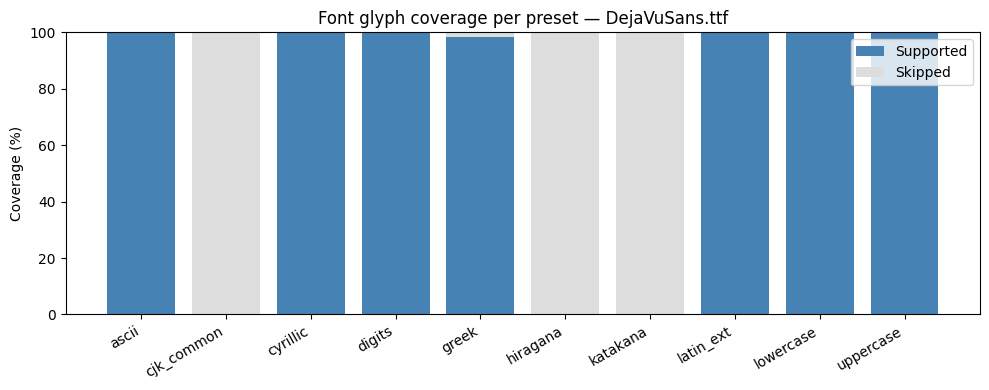

In [7]:
import matplotlib.pyplot as plt

results = []
for name in sorted(PRESET_NAMES):
    chars, skipped = build_charset(name, font_path=FONT)
    total = len(chars) + len(skipped)
    results.append((name, len(chars), len(skipped), total))

# table
print(f"{'Preset':<14} {'Total':>7} {'Supported':>10} {'Skipped':>8} {'Coverage':>9}")
print("-" * 54)
for name, sup, skip, total in results:
    pct = sup / total * 100 if total else 0
    print(f"{name:<14} {total:>7} {sup:>10} {skip:>8} {pct:>8.1f}%")

# bar chart
names   = [r[0] for r in results]
sup_pct = [r[1] / r[3] * 100 for r in results]
skip_pct = [r[2] / r[3] * 100 for r in results]

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(names))
ax.bar(x, sup_pct,  label="Supported", color="steelblue")
ax.bar(x, skip_pct, bottom=sup_pct, label="Skipped", color="#dddddd")
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Coverage (%)")
ax.set_title(f"Font glyph coverage per preset — {FONT.split('/')[-1]}")
ax.legend()
plt.tight_layout()
plt.show()

## 6. `supported_codepoints` — Low-level Access / 低レベルアクセス

Returns a raw `set[int]` of all Unicode codepoints the font covers.
Useful when you want to check coverage without building a full charset.
/ フォントがカバーするコードポイントの生の集合を返す。

In [8]:
cps = supported_codepoints(FONT)
print(f"Total codepoints: {len(cps)}")

# spot checks
for char in ["A", "あ", "α", "→", "漢"]:
    print(f"  U+{ord(char):04X} {char!r:>4} : {'covered' if ord(char) in cps else 'not covered'}")

Total codepoints: 5918
  U+0041  'A' : covered
  U+3042  'あ' : not covered
  U+03B1  'α' : covered
  U+2192  '→' : covered
  U+6F22  '漢' : not covered


## Summary / まとめ

| Function | Purpose |
|----------|---------|
| `get_preset(name)` | Expand a named preset into a character list |
| `from_range(start, stop)` | Generate characters from a Unicode range |
| `supported_codepoints(font_path)` | Get all codepoints covered by a font |
| `filter_by_font(chars, font_path)` | Split into `(supported, skipped)` |
| `build_charset(names, font_path)` | All-in-one: expand + deduplicate + filter |

**Input spec priority in `build_charset`** / `build_charset` の解釈順:
1. Preset name (`"hiragana"`)
2. Unicode range string (`"U+3041-U+3097"`)
3. Literal characters (`"あいうえお"` or `["A", "B"]`)